## 交易历史记录分析脚本

读取 data/history.jsonl，输出多维度分析报告并生成图表。

分析维度:
1. 事件概览         — 各类事件的数量占比
2. 成交分析         — 按证券汇总成交量、成交额、笔数、均价
3. 价格走势         — 各证券成交价格随时间变化
4. 股东活跃度       — 按股东统计委托笔数、成交量
5. 拒绝分析         — 拒绝原因分类，对敲检测命中率
6. 撤单分析         — 撤单成功率、撤单量占比
7. 买卖方向分析     — 买卖双方的委托量和成交量对比
8. 成交价格分布     — 各证券成交价格的直方图

In [1]:
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Noto Sans CJK JP"]
# plt.rcParams['font.family'] = ["Noto Sans"]
plt.rcParams["axes.unicode_minus"] = False

from analyze_history import analyze_price_trend, analyze_shareholders, analyze_rejections, analyze_sides, analyze_price_distribution, load_history, analyze_overview, analyze_executions, analyze_cancels

In [2]:
import os

input_path = "../data/history.jsonl"

if not os.path.exists(input_path):
    print(f"文件不存在: {input_path}")
    print("请先运行:")
    print("python scripts/generate_orders.py")
    print("./bin/generate_history")
    
print(f"加载数据: {input_path}")
df = load_history(input_path)
print(f"共 {len(df)} 条记录")

加载数据: ../data/history.jsonl
共 1284 条记录


In [3]:
import matplotlib.font_manager as fm
fonts = [f for f in fm.fontManager.get_font_names()]
print(sorted(set(fonts)))

['DejaVu Sans', 'DejaVu Sans Display', 'DejaVu Sans Mono', 'DejaVu Serif', 'DejaVu Serif Display', 'Noto Sans CJK JP', 'Noto Serif CJK JP', 'STIXGeneral', 'STIXNonUnicode', 'STIXSizeFiveSym', 'STIXSizeFourSym', 'STIXSizeOneSym', 'STIXSizeThreeSym', 'STIXSizeTwoSym', 'Ubuntu', 'Ubuntu Mono', 'Ubuntu Sans', 'Ubuntu Sans Mono', 'cmb10', 'cmex10', 'cmmi10', 'cmr10', 'cmss10', 'cmsy10', 'cmtt10']


In [4]:
analyze_overview(df)


  1. 事件概览
  ORDER_NEW               468  ( 36.4%)
  EXECUTION               316  ( 24.6%)
  ORDER_CONFIRM           286  ( 22.3%)
  ORDER_REJECT            182  ( 14.2%)
  CANCEL_REJECT            19  (  1.5%)
  CANCEL_CONFIRM           13  (  1.0%)
  总计                     1284


event
ORDER_NEW         468
EXECUTION         316
ORDER_CONFIRM     286
ORDER_REJECT      182
CANCEL_REJECT      19
CANCEL_CONFIRM     13
Name: count, dtype: int64


  2. 成交分析（按证券）
            成交笔数      成交量         成交额      最高价      最低价       均价
securityId                                                      
000001        75  18700.0    279257.0    15.99    13.76    14.93
600030        22   6100.0    188471.0    31.99    28.85    30.78
600519        61  18000.0  32372571.0  1819.12  1786.22  1798.54

  总成交量: 42,800.0  总成交额: 32,840,299.00


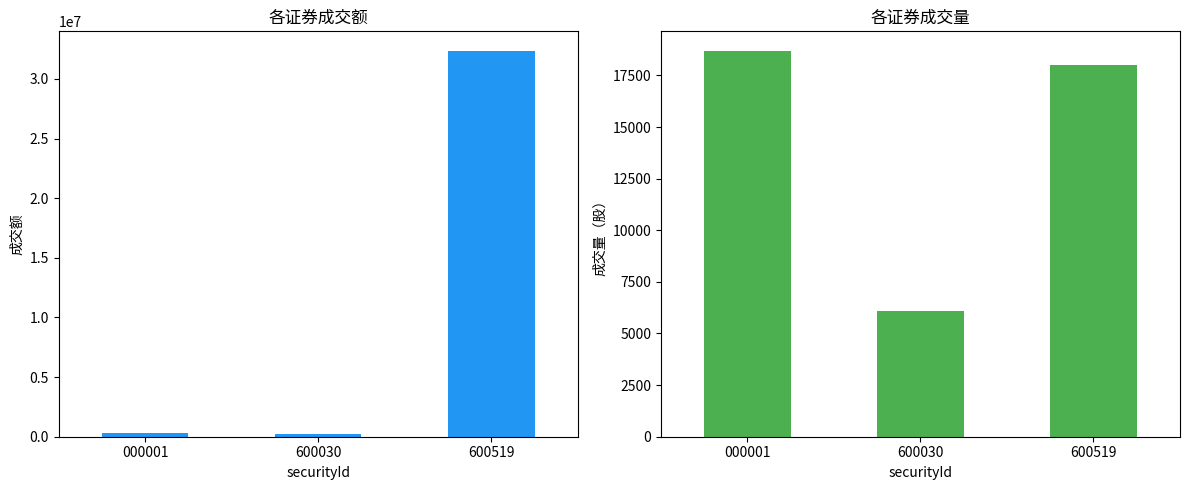

In [5]:
analyze_executions(df)


  3. 价格走势


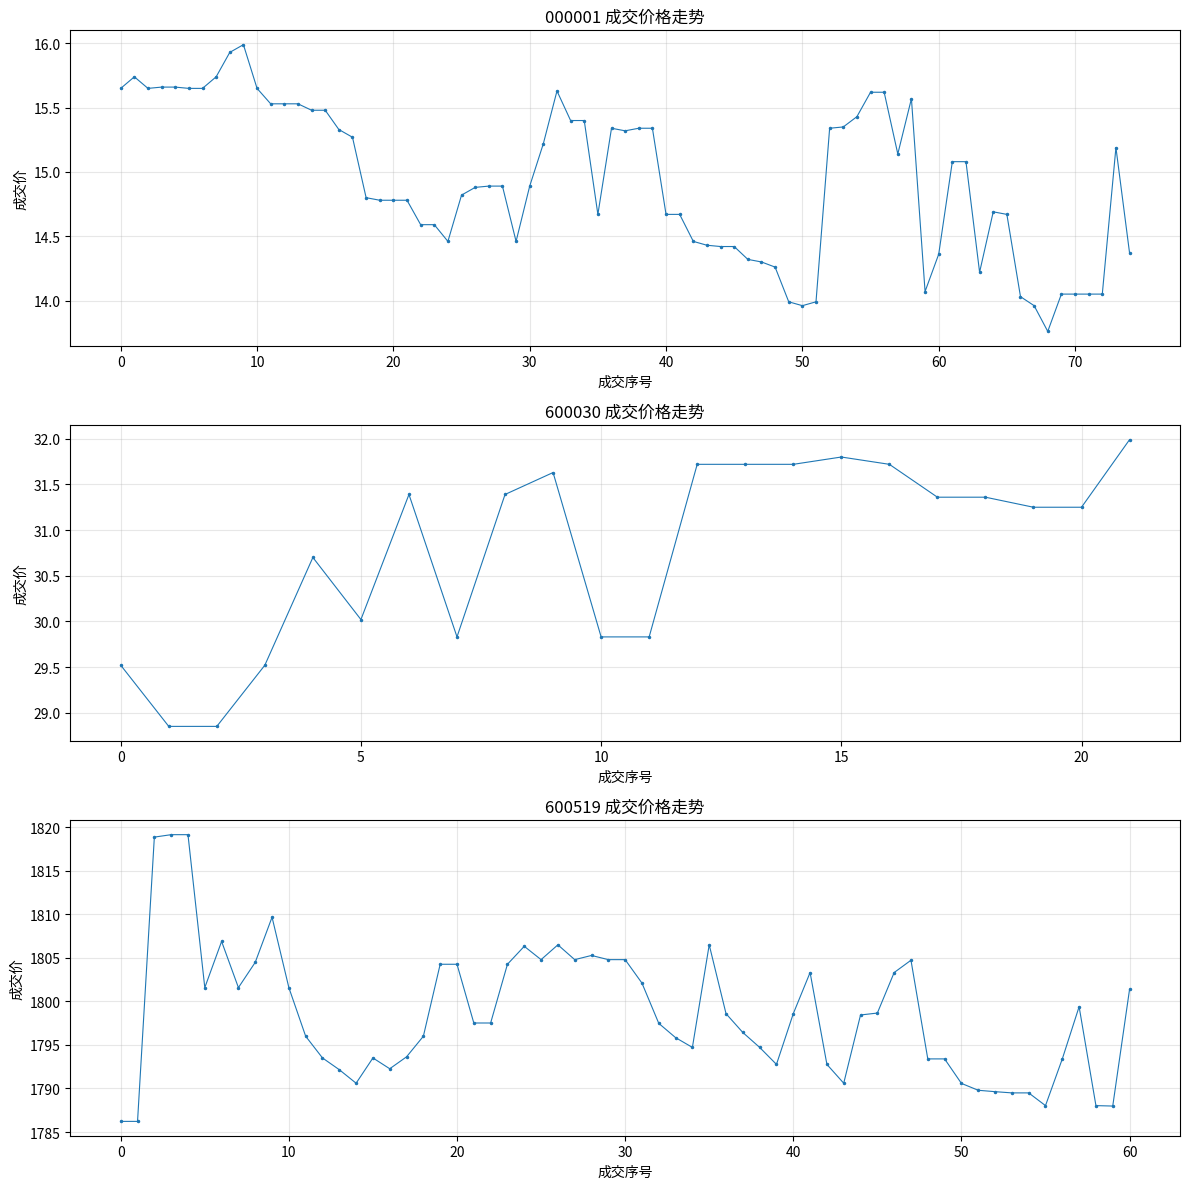

In [6]:
analyze_price_trend(df)


  4. 股东活跃度
               委托笔数      委托量    成交量  成交笔数
shareholderId                            
SH003            47  25800.0  11500    36
SH006            55  24300.0  10400    33
SH008            59  24200.0  10400    34
SH004            45  21700.0   4900    21
SH001            40  21400.0  10700    40
SH009            43  19900.0   5000    21
SH005            48  19800.0   9900    41
SH007            46  18400.0   8900    37
SH010            42  17800.0   7300    25
SH002            43  15800.0   6600    28


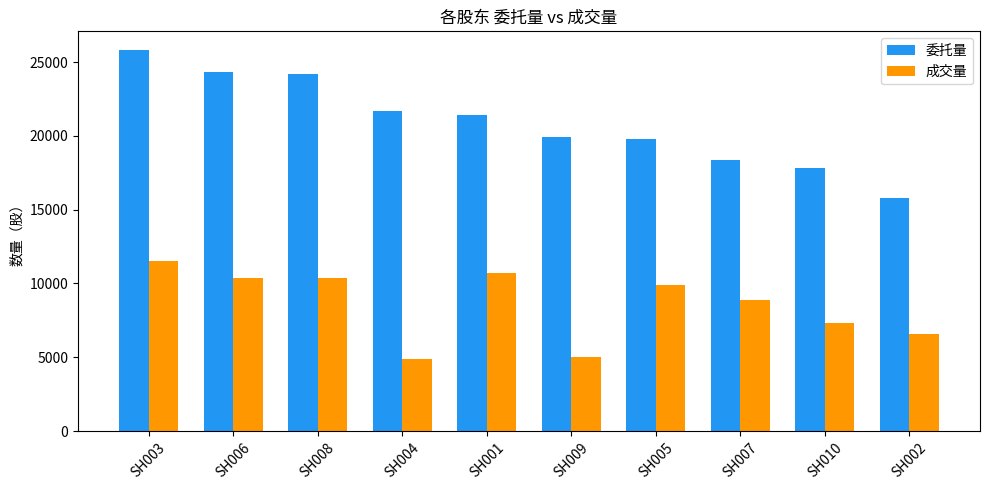

In [7]:
analyze_shareholders(df)


  5. 拒绝分析
  总委托: 468, 拒绝: 182, 拒绝率: 38.9%

  拒绝原因分布:
    Cross trade detected                      182  (100.0%)


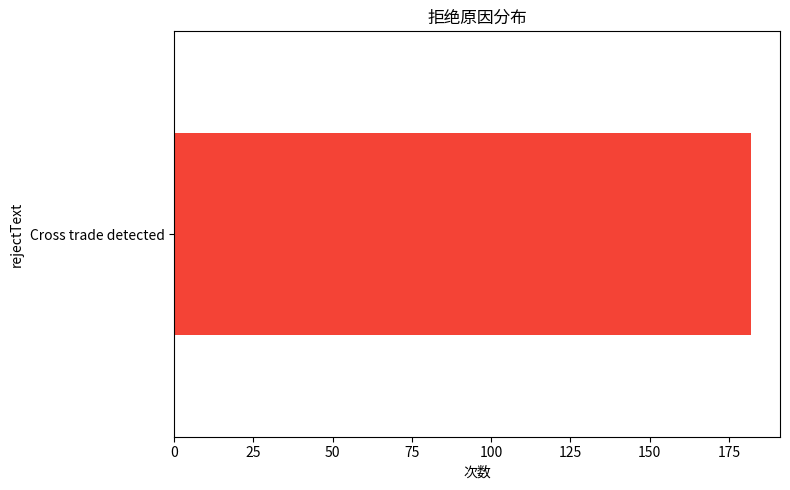

In [8]:
analyze_rejections(df)

In [9]:
analyze_cancels(df)


  6. 撤单分析
  撤单请求: 32
  撤单成功: 13 (40.6%)
  撤单拒绝: 19 (59.4%)
  撤回总量: 6,100.0 股
  已成交量: 400.0 股（撤单前已部分成交）



  7. 买卖方向分析
       委托笔数       委托量
side                 
买入(B)   225  102700.0
卖出(S)   243  106400.0

  被动方（maker）成交方向:
       成交笔数      成交量
side                
买入(B)    94  26500.0
卖出(S)    64  16300.0


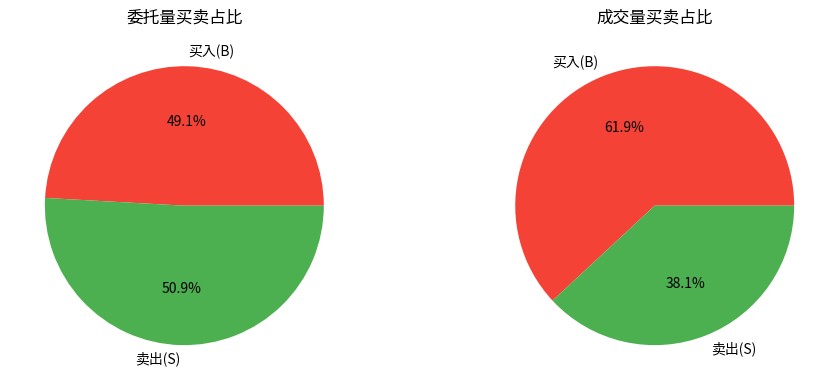

In [10]:
analyze_sides(df)


  8. 成交价格分布


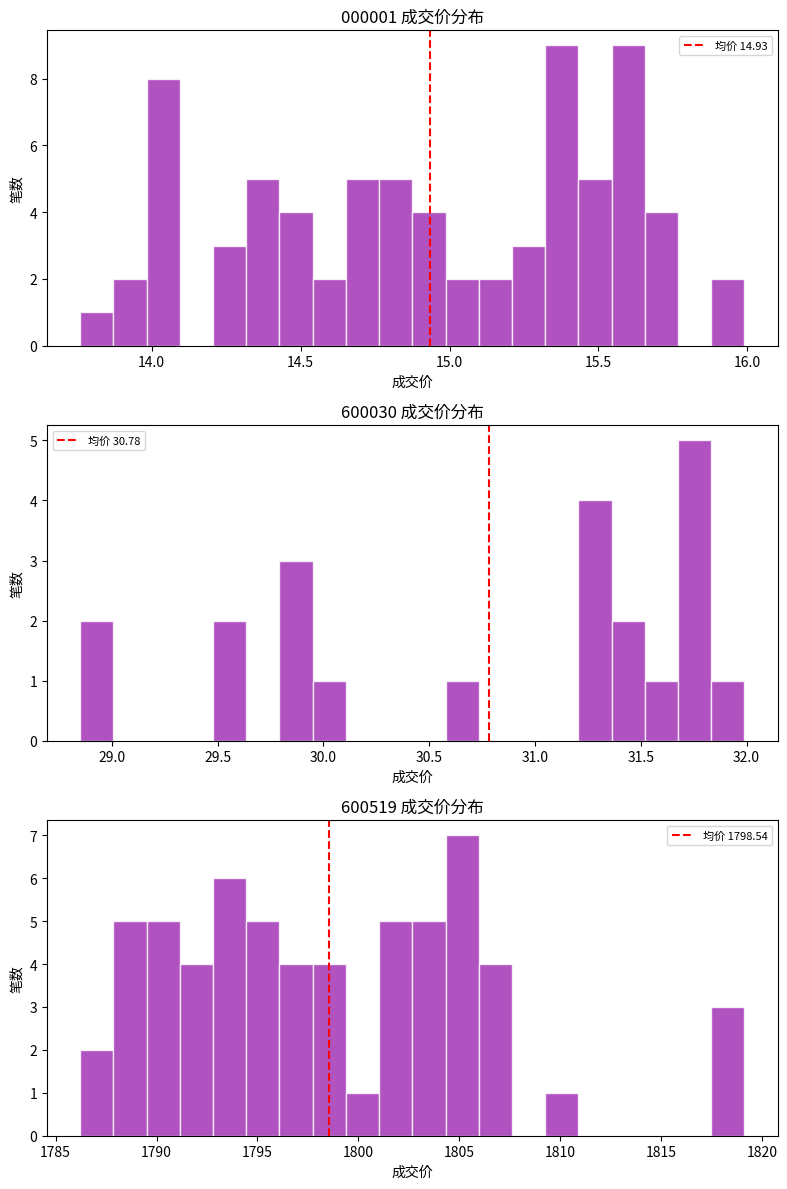

In [11]:
analyze_price_distribution(df)